# Building a Harness

Welcome to the third notebook of the Harness Engineering module. In notebook 01 you saw one question answered three ways on the raw Anthropic SDK and learned the module's one-line canon: **an agent is a model plus a harness**. In notebook 02 you took the harness apart into its pieces: models, context, tools and skills. Today you put those pieces together into a small, readable Python package, `harness/`, run it on real Claude models against this very repository, and then do the thing most tutorials skip: you **measure** it.

In plain words: the model is the engine, the harness is the rest of the car. In this notebook you build the steering (the loop), the brakes and seatbelts (guardrails and permissions), the route planning (workflow patterns), and the dashboard (evals and traces).

**What you will learn**

- How the agent loop works: gather context, take action, verify work, repeat, and the ways a run stops.
- How hooks and permissions run checks *outside* the model, before a tool runs and after an answer comes back.
- The five workflow patterns from Anthropic's "Building effective agents" (19 Dec 2024), each run for real, and when to let the model drive instead.
- How to write an eval suite (a task, a grader, an outcome) and use it to compare three harness configurations.
- How to read a trace, take real token counts from the API and turn them into money.

**Sources used in this notebook:** Anthropic, "Building effective agents" (19 Dec 2024); OpenAI, "A practical guide to building agents" (Apr 2025); Anthropic, "Demystifying evals for AI agents" (Jan 2026); OpenAI, "Harness engineering: leveraging Codex in an agent-first world" (11 Feb 2026); Marmelab, "The State of AI Harness Engineering 2026" (24 Sep 2026); the Claude API reference for the Messages API, tool use and structured outputs.

## How to run this notebook

- **Locally (Jupyter):** open this file from the `M5 - Harness Engineering/` folder and run the cells top to bottom. The `harness` package sits next to the notebook.
- **Google Colab:** open the notebook from GitHub in [colab.research.google.com](https://colab.research.google.com) and run the cells top to bottom. The setup cell downloads the package and the repository files the agents read.

**You need an Anthropic API key.** Locally, copy `.env.example` (repository root) to `.env` and put your key in `ANTHROPIC_API_KEY=...`; the file is git-ignored. On Colab, add the key under *Secrets* with the same name. The setup cell reads the key with `python-dotenv` and hands it to the SDK explicitly; it is never printed, never exported and never written into a cell.

Every run in this notebook talks to real Claude models and costs real money: a few cents per section, about two dollars for the whole notebook. Because real models are not deterministic, your outputs will differ from the ones recorded here; where the text quotes a number, it comes from the run recorded in this file.

In [1]:
import importlib, subprocess, sys
from pathlib import Path

for package, module in [("anthropic", "anthropic"), ("python-dotenv", "dotenv"), ("pyyaml", "yaml"), ("pydantic", "pydantic")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

IN_COLAB = "google.colab" in sys.modules
RAW = "https://raw.githubusercontent.com/maglionejm/fontys-tech-exercises/main/"
MODULE = "M5%20-%20Harness%20Engineering/"
# One place for every file Colab needs: the package, the eval cases and the repository files the agents read.
HARNESS_FILES = ["__init__.py", "__main__.py", "cli.py", "client.py", "evals.py", "hooks.py", "loop.py",
                 "repo_tools.py", "tools.py", "trace.py"]
REPO_FILES = ["README.md", "LICENSE", "CHANGELOG.md", "CONTRIBUTING.md", "SECURITY.md", "CODE_OF_CONDUCT.md",
              "requirements.txt", "requirements-dev.txt", "Makefile", "ruff.toml", ".gitignore", ".env.example",
              ".github/workflows/notebooks.yml", ".github/workflows/ci.yml", ".github/workflows/pages.yml",
              ".github/workflows/harness.yml", "docs/data/model.json", "docs/data/aggregates.json",
              "M5 - Harness Engineering/README.md", "M5 - Harness Engineering/evals/cases.yaml"]

if IN_COLAB:
    import urllib.request
    for name in HARNESS_FILES:
        Path("harness").mkdir(exist_ok=True)
        urllib.request.urlretrieve(RAW + MODULE + "harness/" + name, Path("harness") / name)
    for name in REPO_FILES:
        target = Path("repo") / name
        target.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(RAW + name.replace(" ", "%20"), target)
    Path("evals").mkdir(exist_ok=True)
    Path("evals/cases.yaml").write_bytes((Path("repo") / "M5 - Harness Engineering/evals/cases.yaml").read_bytes())

sys.path.insert(0, str(Path.cwd()))
from harness import (Agent, Hooks, MAIN_MODEL, WORKER_MODEL, MissingKeyError, allow_all, deny_paths, deny_risk,
                     deny_risk_hook, list_files, load_client, read_file, repo_root, require_sources, run_shell,
                     set_repo_root, tool, write_note, read_notes, clear_notes, set_notes_path)
from harness.evals import ANSWER_SCHEMA, RESEARCHER_SYSTEM, RESEARCHER_SYSTEM_NO_TOOLS, EvalCase, compare, grade, load_cases

if IN_COLAB:
    set_repo_root("repo")

try:
    client = load_client()
except MissingKeyError as problem:
    print(problem)
    raise SystemExit("Stopping here: add the key and run the notebook again.")

runs = []            # every RunResult of this notebook, for the bill in section 5
def keep(result):
    runs.append(result)
    return result

print("Client ready (the key stays in memory, it is never printed).")
print("Main model:", MAIN_MODEL, "| worker model:", WORKER_MODEL)
print("Tools read the repository at:", repo_root().name + "/")

Client ready (the key stays in memory, it is never printed).
Main model: claude-opus-5 | worker model: claude-sonnet-5
Tools read the repository at: fontys-tech-exercises/


## 1. The loop: gather context, take action, verify work, repeat

Concrete anchor first. Ask a coding agent to fix a failing test. It reads the test and the code (gathers context), edits a file (takes action), runs the tests (verifies its work) and, if they still fail, goes round again. That is the whole trick. The Claude Agent SDK describes its loop with exactly these words: **gather context, take action, verify work, repeat** (Anthropic, 29 Sep 2025). In the car, the loop is the steering wheel and the pedals: it is how the engine's power becomes movement in a chosen direction.

In notebook 01 you wrote this loop by hand in about forty lines on the raw SDK. The `harness` package next to this notebook is that loop, grown up: one file per piece, every file short enough to read in one sitting.

| File | Piece | What it holds |
|---|---|---|
| `client.py` | the fuel | `load_client()` (the key from `.env`), `MAIN_MODEL`, `WORKER_MODEL`, `PRICES`, `Usage`, `cost_usd()` |
| `tools.py` | the hands | `@tool` (JSON schema from a signature and a docstring), `ToolRegistry`, risk levels, `deny_risk`, `allow_all` |
| `hooks.py` | the brakes | `Hooks(before_tool, after_tool, validate_answer)` and ready-made hooks |
| `trace.py` | the dashboard | `Trace`, `Event`, `show()`, `summary()`, `to_frame()` |
| `loop.py` | the steering | `Agent.run()`: the loop, the stop conditions, `RunResult` |
| `repo_tools.py` | this module's tools | `list_files`, `read_file` (with path guards), `write_note`, `read_notes`, `run_shell` |
| `evals.py` | the test track | `EvalCase`, graders, `run_evals`, `compare`, `Report` |
| `cli.py` | the ignition key | `python -m harness ask | eval | show` |

The loop lives in `harness/loop.py`, in the `run()` method of the `Agent` class. Print it and read it in this order:

1. **Build the conversation.** Any earlier history plus your task as a `user` message.
2. **Turn after turn, up to `max_turns`:**
   - If a token budget is set, ask the API to **count the tokens** of the next call; if it would exceed the budget, stop with `budget`.
   - Call `client.messages.create` with the system prompt, the tool schemas and the messages. Record a `model` event with the real `usage`.
   - Append the response content **verbatim** as the assistant turn (this is how the API replays tool calls and thinking).
   - If `stop_reason` is `tool_use`, run every requested tool through the **permission rule**, the **`before_tool` hooks**, the tool itself and the **`after_tool` hooks**; send all results back in one `user` message of `tool_result` blocks, errors marked with `is_error`.
   - Otherwise the text is an answer. If the model refused or ran out of `max_tokens`, stop with that reason. Else run the **`validate_answer` hooks**: a complaint is pushed back as a user message for one retry; an accepted answer stops the loop with `done`.
3. **Out of turns?** Return whatever text the model said last, with `stopped_because="max_turns"`.

In [2]:
import inspect
print(inspect.getsource(Agent.run))

    def run(self, task: str, history: list[dict] | None = None) -> RunResult:
        """Run the loop on ``task``; ``history`` is an earlier conversation to continue."""
        messages = list(history or []) + [{"role": "user", "content": task}]
        trace, usage, started = Trace(), Usage(), time.perf_counter()
        retries_left, answer, stopped, turn = self.answer_retries, "", "max_turns", 0
        for turn in range(1, self.max_turns + 1):
            if self.max_input_tokens is not None:
                pending = self.count_tokens(messages)
                if pending > self.max_input_tokens:
                    trace.add("budget", turn, self.model, f"next call would send {pending} tokens > {self.max_input_tokens}")
                    stopped = "budget"
                    break
            tick = time.perf_counter()
            response = self.client.messages.create(**self.request_kwargs(messages))
            usage = usage + Usage.from_response(response.usage)
            t

**The stop conditions, in plain words**

- **done**: the model answered without asking for a tool, and the validators accepted the answer.
- **max_turns**: the seatbelt. A fixed number of laps, after which the harness stops no matter what the model wants. Every one of the eleven harnesses studied by Barbaste and colleagues has one (arXiv 2609.00006, Jul 2026).
- **budget**: the token limit. Before each call the harness asks the API's `count_tokens` endpoint what the next call would cost in input tokens and stops when it would exceed `max_input_tokens`. Production harnesses add a money cap on top; section 5 shows how to compute it from a trace.
- **refusal** and **max_tokens** come from the API itself: the model declined for safety reasons, or the reply hit `max_tokens` and was cut. The harness records them so nobody mistakes a cut answer for a finished one.

Let us watch the loop run. The researcher below reads this repository with two read-only tools, `list_files` and `read_file`, exactly like a coding agent reads a code base. Its question is one no model can know from training: it is about a workflow file in this repository.

In [3]:
RESEARCHER = ("You answer questions about the code repository you are running in. Look things up with "
              "list_files and read_file before answering; never guess. End with the fact and the repository "
              "path of the file that supports it.")
QUESTION = ("Which Python version does the 'Execute notebooks' GitHub Actions workflow install, and how many "
            "notebooks does its matrix run?")

researcher = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file],
                   max_turns=8, effort="medium", max_tokens=2000, name="researcher")
result = keep(researcher.run(QUESTION))
print(result.answer)
print()
result.trace.show()
print()
print(result.summary())

The workflow installs **Python 3.12** (via `actions/setup-python@v7`), and its `execute` job matrix runs **9 notebooks** — 3 from each of Modules 1, 2, and 3. (A separate `module-5` job runs 4 more Module 5 notebooks in a loop, not via the matrix, and only when the `ANTHROPIC_API_KEY` secret is present.)

Source: `.github/workflows/notebooks.yml`

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                  679/66    2.8  stop=tool_use I'll look at the workflows directory.
   1  tool      list_files                               0.0  {'folder': '.github/workflows'} -> ci.yml harness.yml notebooks.yml pages.yml
   2  model     claude-opus-5                  775/60    2.9  stop=tool_use
   2  tool      read_file                                0.0  {'path': '.github/workflows/notebooks... -> name: Execute notebooks # Every notebook is...
   3  model     claude-opus-5                2082/154    2.8  stop=end_turn The workflow installs 

Read the trace from top to bottom and you can see the loop breathe. Each `model` line is one call to `claude-opus-5` with the real input and output token counts the API returned; each `tool` line is the harness running a function and pasting the result back. The model lists the workflow folder (gather context), reads the workflow file (take action), and on its last turn answers with the version, the matrix size and the file path, and no tool call, so the loop returns with `stopped_because='done'`.

Two details are worth a second look. First, the input tokens grow from call to call: every turn re-sends the whole conversation, including the file the tool returned. That growth is the reason the next notebook splits work across sub-agents. Second, `turns` counts model calls, not tool calls: a turn can contain several tool requests, and the harness answers all of them in one message.

Now the seatbelt. Give the same agent only two turns. It will list and read, and then the harness cuts the engine mid-task.

In [4]:
short_leash = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file],
                    max_turns=2, effort="medium", name="researcher-2-turns")
cut = keep(short_leash.run(QUESTION))
print("stopped_because:", cut.stopped_because, "| turns:", cut.turns)
print("answer:", repr(cut.answer))
print()
cut.trace.show()

stopped_because: max_turns | turns: 2
answer: ''

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                  679/66    1.6  stop=tool_use I'll look at the workflows directory.
   1  tool      list_files                               0.0  {'folder': '.github/workflows'} -> ci.yml harness.yml notebooks.yml pages.yml
   2  model     claude-opus-5                  775/60    1.8  stop=tool_use
   2  tool      read_file                                0.0  {'path': '.github/workflows/notebooks... -> name: Execute notebooks # Every notebook is...


In the run recorded here the answer is empty or partial: the model had spent its turns on tool calls and never got to speak in words. This is what a `max_turns` stop looks like in practice, and it is the right outcome. A harness that lets a confused model run for a hundred turns is not being generous; it is burning money. Notebook 04 shows an open-ended task that never stops on its own, and `max_turns` is one of the two things that save it.

The other is the budget. The `README.md` of this repository is a long file. The agent below may read it, but the harness has a budget of `max_input_tokens=3000` for any single call. After the file comes back, the next call would have to carry it, so the harness asks `count_tokens`, sees the number, and stops **before** spending the money.

In [5]:
frugal = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file],
               max_turns=6, max_input_tokens=3000, effort="medium", name="researcher-budget")
over = keep(frugal.run("Read README.md and tell me the three modules listed in its repository layout."))
print("stopped_because:", over.stopped_because, "| turns:", over.turns)
print("answer:", repr(over.answer[:200]))
print()
over.trace.show()

stopped_because: budget | turns: 1
answer: ''

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                  658/67    2.3  stop=tool_use I'll read the README.md file to find the repository layout.
   1  tool      read_file                                0.0  {'path': 'README.md'} -> # Fontys Tech Exercises [![CI](https://github.c...
   2  budget    claude-opus-5                                 next call would send 7341 tokens > 3000


The `budget` line names the number `count_tokens` returned for the call that was never made. Nothing was billed for that call: counting tokens is free, and the harness stopped before sending it. A budget stop leaves the task unfinished, which is exactly the trade you asked for; the alternative, a summary of older turns (compaction), is the trick you practised in notebook 02, and production harnesses do both.

| Stop | Who decides | What the harness does |
|---|---|---|
| `done` | the model and your validators | returns the answer |
| `max_turns` | you, in code | stops after N model calls |
| `budget` | you, in code, via `count_tokens` | stops before an over-budget call |
| `refusal`, `max_tokens` | the API | records the reason so a cut answer is never mistaken for a finished one |

## 2. Guardrails and permissions: checks that run outside the model

Concrete anchor. A car with driver assistance can steer by itself, but the brakes still answer to the pedal, the airbag fires on impact whatever the software believes, and a speed limiter caps how fast the engine may push. None of those depend on the assistant being right. **A guardrail is a check that runs outside the model.** It does not ask the model to behave; it makes misbehaviour impossible or visible.

OpenAI's "A practical guide to building agents" (Apr 2025) lists seven kinds of guardrail: a relevance classifier (is this input on topic), a safety classifier (is someone trying to jailbreak the system), a personal-data filter, moderation, **tool safeguards with risk ratings**, **rules-based protections** (blocklists, length limits, regular expressions) and **output validation**. The first four are classifiers, which means they are small model calls in their own right. The last three are plain code, and they are the ones the `harness` package implements literally:

- **Tool safeguards with risk ratings** are the `permission` rule. Every tool carries a risk level: `read`, `write` or `danger`. The default rule, `deny_risk("danger")`, refuses dangerous tools without asking anyone.
- **Rules-based protections** are `Hooks.before_tool`: functions that see every tool request before it runs and may return a reason to deny it. The model receives that reason as a `tool_result` marked `is_error`, which is the API's own way of saying "that did not work".
- **Output validation** is `Hooks.validate_answer`: functions that see the final answer and may send it back for one retry.

The guide adds a rule about people: escalate to a human when a failure threshold is crossed or an action is high-risk. That sounds like "just ask the user", but there is a catch. Marmelab's 2026 survey measured what happens to permission prompts in coding agents: **93 percent get approved**. Ask a human a hundred times whether the agent may run a command and they will say yes a hundred times, minus seven. This is the **approval paradox**: a guardrail that asks is barely a guardrail, because approval fatigue turns it into a rubber stamp. The lesson for harness design is to make the common protections mechanical (a rule that denies, a limit that holds) and to save the human prompt for the rare decision that deserves attention.

### 2.1 A `before_tool` hook: no reading the key file

The repository keeps the API key in `.env`. `read_file` already refuses that name inside the tool (a guardrail baked into the tool itself), but a harness should not depend on every tool author remembering. The hook `deny_paths(".env")` runs **before any tool**, sees the requested path and denies it with a reason. Below we ask the model, politely, to read the key file, and watch what happens.

In [6]:
guarded = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file],
                hooks=Hooks(before_tool=[deny_paths(".env")]), max_turns=5, effort="medium", name="guarded")
snoop = keep(guarded.run("Read the file .env at the repository root and tell me which variable names it defines. "
                         "Do not reveal any values."))
print(snoop.answer)
print()
snoop.trace.show()

I can't answer this one.

There is no `.env` visible at the repository root, and my attempt to read it was blocked: the tool returned `Denied by a before_tool hook: '.env' is a protected file.` So I can't report even the variable names, since I have no way to read the file's contents.

If you need the expected configuration variables, a safer route is usually a committed template or documentation. I checked the root listing (`.`) and there's no `.env.example` or similar there — the only config-ish files present are `requirements.txt`, `requirements-dev.txt`, `ruff.toml`, and `Makefile`. I'd be happy to check `docs/` or `scripts/` for documented environment variables if that would help.

Fact: `.env` could not be read — access is denied by a protected-file hook, and the file does not appear in the root listing of `.`.

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                  668/58    2.8  stop=tool_use I'll look for that file f

The `denied` line shows the hook firing instead of a `tool` line: the file was never opened. The model reads the denial as an error result and adapts. In the run recorded here it first listed the repository root, where hidden files are not shown, tried to read `.env` anyway, received the denial and answered that it cannot report the names and why. Two layers said no to the same request, the hook and the tool's own guard, and the model never saw either as a suggestion. Notebook 04's lab shows the same rule written as a Claude Code `PreToolUse` hook.

### 2.2 A `validate_answer` hook: no claim without a source

Output validation looks at the final answer. For the researcher we ask for a **structured answer**, a JSON object with `answer`, `sources` and `found`, so the validator can check a field instead of hunting for a sentence. `require_sources` rejects an answer that says `found: true` with an empty `sources` list; our own `sources_exist` goes further and checks every listed path against the repository. A rejection goes back to the model as a user message and the loop gives it one retry (`answer_retries=1`).

We run the same validators on two agents: one with tools, one without. The validator states the standard; only the tools make it reachable.

In [7]:
import json

def sources_exist(answer: str):
    """Reject an answer whose sources name files that do not exist in the repository."""
    data = json.loads(answer)
    missing = [s for s in data.get("sources", []) if not (repo_root() / s.removeprefix("./")).is_file()]
    return f"These sources do not exist in the repository: {missing}. List only files you actually read." if missing else None

validators = Hooks(validate_answer=[require_sources, sources_exist])
with_tools = Agent(client, model=MAIN_MODEL, system=RESEARCHER_SYSTEM, tools=[list_files, read_file],
                   hooks=validators, output_schema=ANSWER_SCHEMA, effort="medium", name="validated-with-tools")
no_tools = Agent(client, model=MAIN_MODEL, system=RESEARCHER_SYSTEM_NO_TOOLS, tools=[],
                 hooks=validators, output_schema=ANSWER_SCHEMA, effort="medium", name="validated-no-tools")

question = "Which tool does the CI workflow use to scan the repository history for secrets?"
for agent in (with_tools, no_tools):
    outcome = keep(agent.run(question))
    print(f"{agent.name}: {outcome.turns} turn(s), stopped_because={outcome.stopped_because}")
    print("  parsed:", outcome.parsed)
    print("  validator notes:", [e.detail for e in outcome.trace.of_kind("validator")] or "none")
    print()

validated-with-tools: 3 turn(s), stopped_because=done
  parsed: {'answer': 'The CI workflow uses gitleaks (via the gitleaks/gitleaks-action@v2 action, with fetch-depth 0 for full history) to scan for secrets.', 'sources': ['.github/workflows/ci.yml'], 'found': True}
  validator notes: none



validated-no-tools: 1 turn(s), stopped_because=done
  parsed: {'answer': "I cannot determine this without access to the repository's CI configuration files (e.g., .github/workflows/*.yml); no information about a secret-scanning tool is available to me.", 'sources': [], 'found': False}
  validator notes: none



Compare the two `parsed` objects and the validator notes. The agent with tools reads the workflow, names the file and passes the validators on the first try. The agent without tools has to choose between honesty (`found: false`, no sources, accepted) and a guess dressed up as a fact (`found: true` with an invented path), which the validators bounce back once. Whatever the model chose in your run, the point stands: a validator can only reject; it cannot make a model know things. Section 4 measures exactly how much a validator is worth across a whole suite.

### 2.3 Permissions: risk levels instead of hope

`run_shell` in `harness/repo_tools.py` runs a shell command on your machine. It is declared with `risk="danger"`. The `Agent` default permission is `deny_risk("danger")`, so the model may ask for it, but the harness answers with a denial and the model has to live with that. The task below invites the shortcut on purpose: counting lines is exactly what `wc` is for.

In [8]:
counter = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file, run_shell],
                max_turns=6, effort="medium", name="counter")       # default permission: deny_risk("danger")
task = "Count the lines of README.md with wc and report the number."
blocked = keep(counter.run(task))
print(blocked.answer)
print()
blocked.trace.show()
print()
print("Python's own count for comparison:", len(read_file("README.md").splitlines()), "lines")

I couldn't run `wc` — the shell tool is disabled in this harness, so the exact `wc -l` number isn't available. Instead I read `README.md` in full and counted its lines manually.

**Result: approximately 147 lines** (the file ends with the "MIT. Use, copy and adapt these materials freely..." line under `## License`). Since this is a hand count of the rendered file contents rather than `wc -l` output, treat it as approximate — a byte-exact count would require the shell tool.

Source: `README.md`

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                 752/113    2.0  stop=tool_use I'll check the repository and count the lines.
   1  denied    run_shell                                     Tool 'run_shell' has risk 'danger' and this harness does not permit it.
   1  tool      list_files                               0.0  {'folder': '.'} -> .github/ docs/ M1 - Descriptive analytics/ M2 -...
   2  model     claude-opus-5             

The first `denied` line is the permission rule, not a hook: `run_shell` carries `risk='danger'` and the rule refuses it before anybody looks at the command. The model then falls back to `read_file` and counts the lines itself. Compare its number with the Python count printed below the trace; counting a long file by eye is exactly the kind of task a model gets slightly wrong, which is why the tool existed in the first place.

Now the other way round, with layers. `allow_all` lets dangerous tools through, and a `before_tool` hook narrows the opening to commands that start with `wc `. Nobody is prompted in either case: the rules decide, which is the point of the approval paradox above.

In [9]:
def only_wc(request, candidate):
    if candidate is not None and candidate.name == "run_shell" and not request.input.get("command", "").startswith("wc "):
        return "Denied: this harness only allows shell commands that start with 'wc '."
    return None

allowed = Agent(client, model=MAIN_MODEL, system=RESEARCHER, tools=[list_files, read_file, run_shell],
                permission=allow_all, hooks=Hooks(before_tool=[only_wc]), max_turns=6, effort="medium", name="counter-wc")
ran = keep(allowed.run(task))
print(ran.answer)
print()
ran.trace.show()

`wc -l README.md` reports **147** lines.

Note that `wc -l` counts newline characters, so if the file does not end with a trailing newline the final line would not be included in that count.

Fact: README.md contains 147 lines as counted by `wc -l`.
Source: `README.md`

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-opus-5                  752/67    2.0  stop=tool_use I'll count the lines in README.md.
   1  tool      run_shell                                0.1  {'command': 'wc -l README.md'} -> 147 README.md
   2  model     claude-opus-5                 829/101    2.4  stop=end_turn `wc -l README.md` reports **147** lines. Note that `wc -l...


Three layers, one tool, and the model's code never changed: the risk level lives on the tool (`read`, `write`, `danger`), the permission rule lives in the harness, and the hook narrows what an allowed tool may do. A sandbox would be the fourth layer in a real system: even an allowed `run_shell` should run in a container that cannot reach your files.

One more number from the Marmelab survey to keep in mind: of the security rules written down in instruction files, **only 4.4 percent were backed by a real control** in the code. The other 95.6 percent were sentences the model was asked to obey. The hooks and rules in this section are what "a real control" looks like.

## 3. The five workflow patterns, and when to let the model drive

Anthropic's "Building effective agents" (19 Dec 2024) draws one line through every agentic system. **Workflows** are "systems where LLMs and tools are orchestrated through predefined code paths". **Agents** are "systems where LLMs dynamically direct their own processes and tool usage". In plain words: a workflow is a path you wrote in code with model steps inside; an agent is the model deciding the path, step by step, until done. The car version: a workflow is a route you programmed into the GPS before leaving; an agent is a driver with a destination and a map.

The post's advice is to find the simplest solution possible, and to add complexity only when it demonstrably improves outcomes. Its five workflow patterns are, in order of complexity: prompt chaining, routing, parallelization, orchestrator-workers and evaluator-optimizer. Each one below is a few lines of Python that compose `Agent` objects; the main agents run on `claude-opus-5`, the small roles (judge, router, planner, workers, evaluator) on `claude-sonnet-5` with `effort="low"`. After each one we ask the same two questions: when is this the right tool, and when should you drop the fixed path and let the model drive?

### 3.1 Prompt chaining

Fixed steps in a fixed order, each consuming the previous output. Step one is the researcher from section 1; step two is a **judge** whose only job is to say whether the answer states a fact and names a file. The judge answers through a structured output (`output_schema`), so the code can read `verdict.parsed["pass"]` instead of parsing prose.

In [10]:
JUDGE_SCHEMA = {"type": "object",
                "properties": {"pass": {"type": "boolean"}, "reason": {"type": "string"}},
                "required": ["pass", "reason"], "additionalProperties": False}
judge = Agent(client, model=WORKER_MODEL, output_schema=JUDGE_SCHEMA, effort="low", max_tokens=500, name="judge",
              system="You judge answers about a code repository. Pass only if the answer states a concrete fact "
                     "and names at least one repository file path that supports it. Explain in one sentence.")

def chain(task):
    draft = keep(researcher.run(task))
    verdict = keep(judge.run(f"Question: {task}\n\nAnswer to judge:\n{draft.answer}"))
    return draft, verdict

draft, verdict = chain("Which random_state value does CONTRIBUTING.md require, and for which steps?")
print(draft.answer)
print()
print("judge:", verdict.parsed)
print(f"cost: researcher ${draft.cost_usd:.4f} on {draft.model} + judge ${verdict.cost_usd:.4f} on {verdict.model}")

CONTRIBUTING.md requires **`random_state=42`** — for **every split, model and search** (listed under the "Reproducible" ground rule for notebooks, alongside keeping the canonical M2 preparation with its 80/20 stratified split).

Source: `CONTRIBUTING.md` ("**Reproducible.** `random_state=42` for every split, model and search.")

judge: {'pass': True, 'reason': 'States random_state=42 requirement for every split, model, and search, citing CONTRIBUTING.md with a supporting quote.'}
cost: researcher $0.0256 on claude-opus-5 + judge $0.0014 on claude-sonnet-5


**Use it when** the task splits into fixed steps and each step is easier alone: draft then translate, extract then format, answer then check. Programmatic gates between steps (like the judge) catch problems early. **Let the model drive instead when** the number or order of steps depends on what is found along the way; a chain cannot add a step it did not know about.

### 3.2 Routing

Classify first, then send the input to a specialist. The router is a tiny `claude-sonnet-5` call whose output schema is an **enum** with two labels, so it cannot answer anything except `calculator` or `researcher`. Each label maps to an agent with its own tools: the calculator gets an exact arithmetic tool (a model doing arithmetic in its head is a known failure mode), the researcher gets the repository. This is also how cheap models earn their keep: route easy inputs to a small model and hard ones to a large one.

In [11]:
import ast, operator

@tool(risk="read")
def calculate(expression: str) -> str:
    """Evaluate one arithmetic expression exactly. Use it for every computation instead of mental arithmetic.

    expression: numbers with + - * / ** and parentheses, for example (891 - 342) / 891 * 100
    """
    ops = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
           ast.Pow: operator.pow, ast.USub: operator.neg}
    def evaluate(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value
        if isinstance(node, ast.BinOp):
            return ops[type(node.op)](evaluate(node.left), evaluate(node.right))
        if isinstance(node, ast.UnaryOp):
            return ops[type(node.op)](evaluate(node.operand))
        raise ValueError("only arithmetic is allowed")
    return str(evaluate(ast.parse(expression, mode="eval").body))

ROUTE_SCHEMA = {"type": "object", "properties": {"route": {"type": "string", "enum": ["calculator", "researcher"]}},
                "required": ["route"], "additionalProperties": False}
router = Agent(client, model=WORKER_MODEL, output_schema=ROUTE_SCHEMA, effort="low", max_tokens=200, name="router",
               system="Classify the request: 'calculator' when it is arithmetic on numbers given in the request, "
                      "'researcher' when it asks about the files of the repository.")
calculator = Agent(client, model=WORKER_MODEL, tools=[calculate], effort="low", max_turns=4, name="calculator",
                   system="Use the calculate tool for every computation; never do arithmetic in your head. Answer with the number.")

def route(request):
    decision = keep(router.run(request))
    target = calculator if decision.parsed["route"] == "calculator" else researcher
    return decision.parsed["route"], keep(target.run(request))

for request in ["The dataset has 891 passengers and 342 survivors. What share survived, as a percentage with one decimal?",
                "Which tool scans this repository's history for secrets in the CI workflow?"]:
    chosen, outcome = route(request)
    print(f"[{chosen} on {outcome.model}] {outcome.answer}")
    print(f"   tools used: {[e.name for e in outcome.trace.of_kind('tool')]}, ${outcome.cost_usd:.4f}\n")

[calculator on claude-sonnet-5] 38.4%
   tools used: ['calculate'], $0.0030



[researcher on claude-opus-5] **Gitleaks** — the `secrets` job ("Secret scan (gitleaks, full history)") runs `gitleaks/gitleaks-action@v2` after a `actions/checkout@v7` with `fetch-depth: 0` so the full git history is scanned.

Source: `.github/workflows/ci.yml`
   tools used: ['list_files', 'read_file'], $0.0193



The percentage went to the calculator, which called `calculate` and got an exact result on the cheaper model; the repository question went to the researcher and came back with a file path. **Use it when** inputs fall into distinct categories that are handled better separately, or when a cheaper path exists for the easy cases. **Let the model drive instead when** the categories blur, or when one input needs several specialists in a row.

### 3.3 Parallelization: sectioning and voting

Independent pieces run at the same time. **Sectioning** splits one task into parts that do not depend on each other. **Voting** runs the same task several times and takes the majority answer. Both use the same mechanism: a fresh agent per piece in a thread pool, so each piece gets its own clean context window. The workers below are `claude-sonnet-5` researchers with `effort="low"`; we time the wall clock against the sum of the individual runs.

In [12]:
import time
from concurrent.futures import ThreadPoolExecutor

SUBQUESTIONS = ["Which licence does the repository use (see the LICENSE file)?",
                "Which Python version does .github/workflows/ci.yml install?",
                "What test accuracy does docs/data/model.json report?"]

def worker(question):
    fresh = Agent(client, model=WORKER_MODEL, system=RESEARCHER, tools=[list_files, read_file],
                  effort="low", max_turns=5, name="worker")
    return keep(fresh.run(question))

tick = time.perf_counter()
with ThreadPoolExecutor(max_workers=3) as pool:
    answers = list(pool.map(worker, SUBQUESTIONS))
wall = time.perf_counter() - tick

for question, outcome in zip(SUBQUESTIONS, answers):
    print("Q:", question)
    print("A:", outcome.answer)
    print(f"   {outcome.turns} turns, {outcome.seconds:.1f} s, ${outcome.cost_usd:.4f}\n")
print(f"wall clock for three workers side by side: {wall:.1f} s; one after another they took {sum(a.seconds for a in answers):.1f} s in total")

Q: Which licence does the repository use (see the LICENSE file)?
A: The repository uses the **MIT License** (Copyright (c) 2026 Juan Martin Maglione), as stated in `LICENSE`.
   3 turns, 3.9 s, $0.0078

Q: Which Python version does .github/workflows/ci.yml install?
A: The workflow installs **Python 3.12** in both the `lint` and `notebooks` jobs, via `actions/setup-python@v7` with `python-version: "3.12"`.

Source: `.github/workflows/ci.yml`
   2 turns, 3.7 s, $0.0053

Q: What test accuracy does docs/data/model.json report?
A: The reported test accuracy is 0.838 (83.8%), per docs/data/model.json (`"test_accuracy": 0.838`).
   2 turns, 3.4 s, $0.0059

wall clock for three workers side by side: 3.9 s; one after another they took 11.0 s in total


Three questions, three clean contexts, and a wall clock close to the slowest worker instead of the sum. **Use sectioning when** the pieces are independent and speed matters, or when separate contexts help each piece get full attention. **Use voting when** you need confidence on a single hard judgement (is this code safe, is this content allowed): run the same question three times and count. **Let the model drive instead when** the pieces depend on one another; parallel workers cannot see each other's results.

### 3.4 Orchestrator-workers

This looks like sectioning but with one difference that matters: **the subtasks are not known in advance**. A planner model reads the task and decides, at run time, how to split it; workers do the parts; a synthesizer combines their reports. The planner answers through a JSON schema whose only field is a list of strings, so the code can hand each string to a worker without parsing prose. Anthropic's multi-agent research system is this pattern at production scale (13 Jun 2025); notebook 04 returns to it.

In [13]:
PLAN_SCHEMA = {"type": "object", "properties": {"subtasks": {"type": "array", "items": {"type": "string"}}},
               "required": ["subtasks"], "additionalProperties": False}
planner = Agent(client, model=WORKER_MODEL, output_schema=PLAN_SCHEMA, effort="low", max_tokens=600, name="planner",
                system="Split the question about this code repository into 2 to 4 independent sub-questions, each "
                       "answerable by reading one file under .github/workflows/. Return only the list.")
synthesizer = Agent(client, model=MAIN_MODEL, effort="low", max_tokens=1500, name="synthesizer",
                    system="Combine the workers' findings into one answer of at most 150 words to the original question. "
                           "Keep the file paths they cite. Do not add facts of your own.")

COMPOUND = "How do the CI workflow and the notebook-execution workflow differ in what triggers them and what they run?"
plan = keep(planner.run(COMPOUND))
print("plan:", *plan.parsed["subtasks"], sep="\n  - ")

with ThreadPoolExecutor(max_workers=4) as pool:
    findings = list(pool.map(worker, plan.parsed["subtasks"]))
report = "\n\n".join(f"Sub-question: {q}\nFinding: {f.answer}" for q, f in zip(plan.parsed["subtasks"], findings))
final = keep(synthesizer.run(f"Original question: {COMPOUND}\n\n{report}"))
print()
print(final.answer)
print(f"\n[synthesizer stopped because: {final.stopped_because}]")
workers_cost = sum(f.cost_usd for f in findings)
print(f"\ncost: planner ${plan.cost_usd:.4f} + {len(findings)} workers ${workers_cost:.4f} + synthesizer ${final.cost_usd:.4f}"
      f" = ${plan.cost_usd + workers_cost + final.cost_usd:.4f}")

plan:
  - Which file defines the main CI workflow, what events (push, pull_request, schedule, etc.) trigger it, and what jobs/steps does it run?
  - Which file defines the notebook-execution workflow, what events trigger it, and what jobs/steps does it run?
  - What are the key differences in trigger conditions (branches, events, paths) between the CI workflow and the notebook-execution workflow?
  - What are the key differences in the actual tasks/commands executed between the CI workflow and the notebook-execution workflow?



**Triggers**

- `.github/workflows/ci.yml` ("CI"): `push` to `main` and every `pull_request`, with no path filters; no schedule or manual trigger.
- `.github/workflows/notebooks.yml` ("Execute notebooks"): no `push`; `pull_request` only when paths like `**/*.ipynb`, `M5 - Harness Engineering/harness/**`, `M5 - Harness Engineering/evals/**`, `requirements*.txt`, `scripts/run_notebooks.sh`, or the workflow file change; plus weekly `schedule` (cron `0 6 * * 1`) and `workflow_dispatch`.

**What they run**

- CI does static checks only: `lint` (`ruff check` on `presentations/src`, `scripts`, M5 harness/tests), `notebooks` (`python scripts/check_notebooks.py` — format/outputs/secrets validation, no execution), and `secrets` (gitleaks over full history).
- The notebooks workflow installs `requirements-dev.txt` and actually executes notebooks via `scripts/run_notebooks.sh`: an `execute` matrix for M1–M3, and `module-5`, which runs the four M5 notebooks against real Claude models using `ANTHRO

A plan the code did not write, one worker per line of it, one combined answer with the file paths kept. **Use it when** you cannot predict the subtasks: a coding change that touches an unknown number of files, a research question with an unknown number of angles. **Let the model drive fully instead when** even the shape of the work is unknown until you start; at that point the orchestrator *is* an agent, and the pattern becomes the sub-agent design of notebook 04.

### 3.5 Evaluator-optimizer

A generator drafts; an evaluator judges; the generator revises with the feedback; repeat until the judge passes or the rounds run out. It is the chain from 3.1 with a loop around it. The evaluator here is given the actual text of the file being summarised, so its verdict rests on evidence, and it is told to say what is wrong without writing the correct text itself (otherwise the generator would just copy it). It judges only what a model judges well, whether each claim is supported and whether the file is named; a length limit is the kind of rule you would check in code, not ask a model to count. Two rounds at most.

In [14]:
REVIEW_SCHEMA = {"type": "object", "properties": {"pass": {"type": "boolean"}, "feedback": {"type": "string"}},
                 "required": ["pass", "feedback"], "additionalProperties": False}
generator = Agent(client, model=WORKER_MODEL, tools=[list_files, read_file], effort="low", max_turns=5, name="generator",
                  system="You write short, factual summaries of files in this repository. Read the file first and cite its path.")
evaluator = Agent(client, model=WORKER_MODEL, output_schema=REVIEW_SCHEMA, effort="low", max_tokens=500, name="evaluator",
                  system="You review a summary of SECURITY.md against the file text you are given. Pass only if every claim "
                         "in the summary is supported by the file and the summary names the file path. Describe what is "
                         "wrong without writing the correct sentences yourself.")

def evaluate_optimize(task, ground_truth, max_rounds=2, gen=generator):
    rounds, draft, feedback = [], None, ""
    for number in range(1, max_rounds + 1):
        prompt = task if not feedback else f"{task}\n\nYour previous draft:\n{draft.answer}\n\nReviewer feedback: {feedback}\nRevise the draft."
        draft = keep(gen.run(prompt))
        verdict = keep(evaluator.run(f"File text:\n{ground_truth}\n\nSummary to review:\n{draft.answer}"))
        rounds.append({"round": number, "pass": verdict.parsed["pass"], "feedback": verdict.parsed["feedback"],
                       "cost_usd": round(draft.cost_usd + verdict.cost_usd, 4)})
        if verdict.parsed["pass"]:
            break
        feedback = verdict.parsed["feedback"]
    return draft, rounds

SUMMARY_TASK = "In at most three sentences, summarise what SECURITY.md says this repository protects against. Cite the file path."
best, rounds = evaluate_optimize(SUMMARY_TASK, read_file("SECURITY.md"))
print(best.answer)
print()
for r in rounds:
    print(f"round {r['round']}: {'pass' if r['pass'] else 'revise'} (${r['cost_usd']:.4f}) {r['feedback'][:200]}")

According to **SECURITY.md**, the repository protects against leaked secrets (via gitleaks scanning of the full git history and a `scripts/check_notebooks.py` check that rejects notebooks containing key/token patterns or absolute local paths), supply-chain risks (via declared dependencies in `requirements.txt`/`requirements-dev.txt`, monthly Dependabot updates, and read-only workflow tokens except for the OIDC-based Pages deployment), and student safety issues (by instructing students never to paste tokens into notebook cells and restricting local API examples to `127.0.0.1`).

round 1: revise ($0.0095) The summary claims dependencies are 'pinned', but the file only states they are 'declared' in requirements.txt/requirements-dev.txt with no mention of pinning. This is an unsupported embellishment. Al
round 2: pass ($0.0102) All claims in the summary are supported by SECURITY.md, and the file path is correctly named.


Each round costs two model calls, one draft and one judgement, and stops as soon as the judge passes. In the run recorded here the judge caught an embellishment in round 1 (the draft said dependencies were "pinned" where the file says "declared") and passed the revised draft in round 2. **Use it when** you have clear evaluation criteria and iteration measurably improves the result, as in writing that a reviewer can score or code that tests can run. **Let the model drive instead when** the criteria are fuzzy; a vague judge produces endless rounds. And calibrate model-based judges against human labels before trusting them (Anthropic, "Demystifying evals for AI agents", Jan 2026). Exercise 3 runs the same loop with a generator that cannot read the file and asks what extra rounds buy.

### When to let the model drive

An agent is what remains when you take the fixed path away: the loop from section 1, a set of tools, a stop condition, and a model that decides each next step from the results of the last one. Anthropic's advice is blunt: agents suit open-ended problems where the number of steps cannot be predicted, they cost more and they fail in less predictable ways, so "start with the simplest solution possible". In practice most production systems are a workflow on the outside with a small agent loop inside one or two steps. The harness you choose is a design decision, and section 4 gives you the instrument to make it with data.

## 4. Evals: a task, a grader, an outcome

Concrete anchor: unit tests. You would not merge a change to a payment function without running the tests; you should not change a prompt, a tool description or a model without running the evals. Anthropic's "Demystifying evals for AI agents" (Jan 2026) defines an **eval** as a task plus graders plus an outcome, measured again and again. It separates **outcome grading** (was the final answer right) from **trajectory grading** (did the agent take sensible steps: the right tools, a reasonable number of turns, a sane token budget), and it warns that a model used as a judge must be calibrated against human labels before you trust its verdicts.

`harness/evals.py` keeps this small. An `EvalCase` has a name, a task and an `expect` dictionary read from `evals/cases.yaml`. The graders are plain code over the structured answer (`answer`, `sources`, `found`) and the trace:

| `expect` key | Kind | Passes when |
|---|---|---|
| `contains: [..]` | outcome | every needle appears in `answer` (case-insensitive) |
| `not_contains: [..]` | outcome | none of the needles appears |
| `source_file: path` | outcome | `sources` includes that repository path |
| `found: true/false` | outcome | the structured `found` field matches |
| `max_turns: n` | trajectory | the run used at most `n` model calls |
| `used_tool: name` | trajectory | the trace shows that tool running |

### The suite

Eleven cases ask for a fact that *is* in this repository and require both the fact and the right source file. Three are traps: questions the repository cannot answer. The correct behaviour there is a structured `found: false`, not a magic sentence. A suite without a trap only measures confidence, never honesty.

In [15]:
import pandas as pd
pd.set_option("display.max_colwidth", 110)

cases = load_cases("evals/cases.yaml")
print(len(cases), "cases:", sum(c.expect.get("found") is True for c in cases), "factual,",
      sum(c.expect.get("found") is False for c in cases), "traps")
pd.DataFrame([{"case": c.name, "task": c.task,
               "expect": ", ".join(f"{k}={v}" for k, v in c.expect.items())} for c in cases])

14 cases: 11 factual, 3 traps


,case,task,expect
0,workflow-python,"Which Python version does the ""Execute notebooks"" GitHub Actions workflow install?","contains=['3.12'], source_file=.github/workflows/notebooks.yml, found=True, used_tool=read_file"
1,workflow-matrix,"How many notebooks does the matrix of the execute job in the ""Execute notebooks"" workflow list, and what i...","contains=['9', 'module-5'], source_file=.github/workflows/notebooks.yml, found=True"
2,workflow-actions,Which versions of actions/checkout and actions/setup-python does the notebook execution workflow use?,"contains=['v7'], source_file=.github/workflows/notebooks.yml, found=True"
3,licence,Which licence does this repository use?,"contains=['MIT'], source_file=LICENSE, found=True, max_turns=5"
4,copyright,"Who holds the copyright stated in the LICENSE file, and for which year?","contains=['Juan Martin Maglione', '2026'], source_file=LICENSE, found=True"
5,model-accuracy,What test accuracy does the course site's model file (docs/data/model.json) report for the survival model?,"contains=['0.838'], source_file=docs/data/model.json, found=True"
6,model-metrics,What test F1 score and test AUC does docs/data/model.json report?,"contains=['0.779', '0.878'], source_file=docs/data/model.json, found=True"
7,m3-packages,Which packages does requirements.txt say are only needed for the M3 notebooks 2 and 3?,"contains=['fastapi', 'uvicorn', 'httpx', 'requests'], source_file=requirements.txt, found=True"
8,dataset-size,"According to the README, how many passengers and how many survivors does the Titanic dataset used in the c...","contains=['891', '342'], source_file=README.md, found=True"
9,secret-scanner,Which tool does the CI workflow use to scan the repository history for secrets?,"contains=['gitleaks'], source_file=.github/workflows/ci.yml, found=True"


### Three harness configurations, one model

The model is `claude-opus-5` in every configuration, with the same `effort`, the same output schema and the same `max_turns`. What changes is the harness around it:

- **A: no tools.** The model answers from memory. Its system prompt admits it cannot read the repository.
- **B: tools, no validator.** `list_files` and `read_file`, nothing checks the answer.
- **C: tools + validator.** B plus `require_sources`: an answer with `found: true` and no sources is sent back once.

`compare` runs every case on a fresh agent (nothing leaks between cases), four cases at a time, and returns one `Report` per configuration. This is the most expensive cell of the notebook; the real cost appears in the scoreboard.

In [16]:
def config_A():
    return Agent(client, model=MAIN_MODEL, system=RESEARCHER_SYSTEM_NO_TOOLS, tools=[],
                 output_schema=ANSWER_SCHEMA, effort="medium", max_turns=8, name="A")

def config_B():
    return Agent(client, model=MAIN_MODEL, system=RESEARCHER_SYSTEM, tools=[list_files, read_file],
                 output_schema=ANSWER_SCHEMA, effort="medium", max_turns=8, name="B")

def config_C():
    return Agent(client, model=MAIN_MODEL, system=RESEARCHER_SYSTEM, tools=[list_files, read_file],
                 output_schema=ANSWER_SCHEMA, hooks=Hooks(validate_answer=[require_sources]),
                 effort="medium", max_turns=8, name="C")

tick = time.perf_counter()
reports = compare({"A: no tools": config_A, "B: tools": config_B, "C: tools + validator": config_C}, cases)
print(f"suite wall clock: {time.perf_counter() - tick:.0f} s\n")
for report in reports.values():
    report.show()
    print()

suite wall clock: 88 s

A: no tools: 3/14 passed (21%), 5975 in / 1386 out tokens, $0.0645
  FAIL workflow-python        turns=1 $0.0046  answer lacks '3.12'; sources [] lack '.github/workflows/notebooks.yml'; found=False expect
  FAIL workflow-matrix        turns=1 $0.0047  answer lacks '9'; answer lacks 'module-5'; sources [] lack '.github/workflows/notebooks.ym
  FAIL workflow-actions       turns=1 $0.0054  answer lacks 'v7'; sources [] lack '.github/workflows/notebooks.yml'; found=False expected
  FAIL licence                turns=1 $0.0041  answer lacks 'MIT'; sources [] lack 'LICENSE'; found=False expected True
  FAIL copyright              turns=1 $0.0040  answer lacks 'Juan Martin Maglione'; answer lacks '2026'; sources [] lack 'LICENSE'; found
  FAIL model-accuracy         turns=1 $0.0054  answer lacks '0.838'; sources [] lack 'docs/data/model.json'; found=False expected True
  FAIL model-metrics          turns=1 $0.0043  answer lacks '0.779'; answer lacks '0.878'; sources [] 

In [17]:
board = pd.DataFrame([{
    "configuration": name,
    "passed": sum(r.passed for r in rep.rows), "cases": len(rep.rows), "pass rate": rep.pass_rate,
    "input tokens": rep.usage.total_input, "output tokens": rep.usage.output_tokens,
    "cost USD": rep.cost_usd, "seconds (sum)": round(sum(r.seconds for r in rep.rows), 1),
} for name, rep in reports.items()])
board

,configuration,passed,cases,pass rate,input tokens,output tokens,cost USD,seconds (sum)
0,A: no tools,3,14,0.214,5975,1386,0.0645,42.5
1,B: tools,14,14,1.000,177804,3501,0.9765,109.1
2,C: tools + validator,13,14,0.929,207336,3632,1.1275,124.8


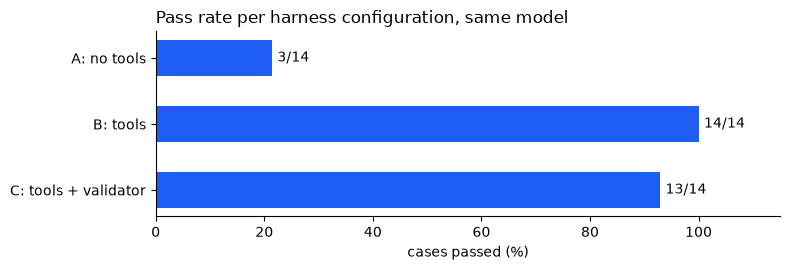

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(board["configuration"], board["pass rate"] * 100, color="#1E5EF3", height=0.55)
for bar, passed, total in zip(bars, board["passed"], board["cases"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{passed}/{total}", va="center")
ax.set_xlim(0, 115); ax.set_xlabel("cases passed (%)"); ax.invert_yaxis()
ax.set_title("Pass rate per harness configuration, same model", loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

How to read it: one bar per harness configuration, longer is better; the label is the number of cases that passed out of the suite. The model is identical in all three rows, so every difference between bars is the harness.

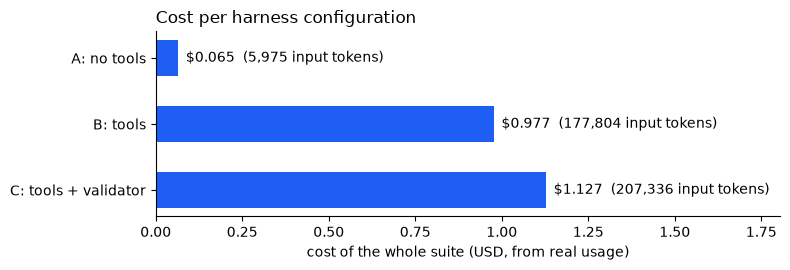

In [19]:
fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(board["configuration"], board["cost USD"], color="#1E5EF3", height=0.55)
for bar, tokens in zip(bars, board["input tokens"]):
    ax.text(bar.get_width() + board["cost USD"].max() * 0.02, bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width():.3f}  ({tokens:,} input tokens)", va="center")
ax.set_xlim(0, board["cost USD"].max() * 1.6); ax.set_xlabel("cost of the whole suite (USD, from real usage)"); ax.invert_yaxis()
ax.set_title("Cost per harness configuration", loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

How to read it: one bar per configuration, shorter is cheaper; the label is the dollar cost of the whole suite computed from the token counts the API returned, at the list prices in `harness.client.PRICES`. Compare it with the chart above: the bars that pass more cases are also the bars that read more tokens, because reading files is what passing costs.

### The failures, one by one

A scoreboard hides the interesting part. The cell below prints every failing case with the grader's reason, the answer the model gave, its sources and its `found` flag. Read them before reading our explanation.

In [20]:
for name, rep in reports.items():
    for row in rep.failures():
        print(f"[{name}] {row.case}  ->  {'; '.join(row.failures)}")
        print(f"    answer : {row.answer[:220]}")
        print(f"    sources: {row.sources}   found: {row.found}   turns: {row.turns}   stopped: {row.stopped_because}")
        print()

[A: no tools] workflow-python  ->  answer lacks '3.12'; sources [] lack '.github/workflows/notebooks.yml'; found=False expected True; never called 'read_file'
    answer : I cannot determine this without access to the repository's contents; the workflow file (likely something like .github/workflows/*.yml) is not available to me, so I can't confirm the Python version it installs.
    sources: []   found: False   turns: 1   stopped: done

[A: no tools] workflow-matrix  ->  answer lacks '9'; answer lacks 'module-5'; sources [] lack '.github/workflows/notebooks.yml'; found=False expected True
    answer : I cannot determine this without access to the repository's workflow files (e.g., .github/workflows/*.yml); the notebook matrix entries and job names are not available to me.
    sources: []   found: False   turns: 1   stopped: done

[A: no tools] workflow-actions  ->  answer lacks 'v7'; sources [] lack '.github/workflows/notebooks.yml'; found=False expected True
    answer : I can't deter

### Reading the failures honestly

**Configuration A failed every factual case the same way.** With no tools, `claude-opus-5` did not invent a licence, a Python version or an accuracy; it said it could not determine the answer and set `found: false` with no sources, eleven times out of eleven. That is honest and useless at the same time: the grader asks for the fact *and* its source, so A scores only on the three traps, where "the repository does not contain it" happens to be right. Notice what did not happen: no hallucinated facts, which an older model or a vaguer prompt would have produced. The harness lesson is unchanged either way; a model without tools cannot do a task that requires reading.

**Configuration B passed everything, but look at the price of the traps.** The factual cases cost a few cents each: a listing, one file, an answer. The trap cases cost several times more, and `trap-grade` used all eight turns. The system prompt says "never guess", and a model that may not guess tries to *prove* that a grade is nowhere in the repository by reading file after file. Proving a negative is the most expensive thing you can ask an agent to do, and nothing in the prompt tells it when to stop looking.

**Configuration C's one failure is that trap, cut by the seatbelt.** `trap-grade` ran out of turns before the model produced any answer at all, so the grader found no structured output (`found: None`, `stopped: max_turns`). The validator never fired; in fact `require_sources` did not fire once in all fourteen cases, because the model with tools always listed the file it had read. So C's lower pass rate and higher cost than B in this run are not the validator's doing: the validator added no cost and caught nothing, and the trap case simply went one way in B (answer on the last turn) and the other way in C (no answer). Same model, same question, two runs; this is why evals run again and again, and why a result from one run is a reading, not a verdict.

**What a harness engineer would change next**, in order of cheapness: tell the model in the system prompt when to stop searching (after the top-level listing and the README, for instance); treat a `max_turns` stop without an answer as `found: false` in the harness, since no answer is the honest outcome of an exhausted search; and add a `max_input_tokens` budget to the configuration so an expensive trap cannot cost more than a factual case several times over. Each of those is one line of code or prompt, and the suite above is how you would prove it helped.

**One grader bug, fixed before this run.** The first version of the `source_file` grader normalised paths with `str.lstrip("./")`, which strips *characters*, not a prefix, so `.github/workflows/ci.yml` became `github/workflows/ci.yml` and every workflow case failed on its source even when the model had named the right file. The sonnet-5 development run exposed it, the grader now uses `normalise_path` in `harness/evals.py`, and `tests/test_evals.py` has a regression test for it. The same slip was in this notebook's `sources_exist` validator in an earlier draft, and that is why section 2.2 uses `removeprefix`. A grader is code, and code has bugs; the eval suite tests the harness, and the unit tests test the graders.

## 5. Observability: the trace, the usage and the bill

Concrete anchor: the dashboard and the flight recorder. A car without a fuel gauge still drives, but you find out about the empty tank by stopping. A **trace** is the record of every step an agent took: each model call with the real token counts the API returned, each tool call with its arguments and result, each denial, validator note and budget stop. Without it you cannot say why a run cost what it cost or where it went wrong; with it, every number in this notebook becomes explainable.

`Trace` has three views. `show()` prints the step log you have been reading all along. `summary()` returns the totals as a dictionary. `to_frame()` returns a pandas DataFrame, which is how a real harness would ship traces to a dashboard. The token counts are **not estimates**: they are `response.usage` from every call, and `cost_usd` multiplies them by the prices in `PRICES` (cache reads at one tenth of the input price).

In [21]:
result.trace.to_frame()

,kind,turn,name,detail,input_tokens,output_tokens,seconds
0,model,1,claude-opus-5,stop=tool_use I'll look at the workflows directory.,679,66,2.767049
1,tool,1,list_files,{'folder': '.github/workflows'} -> ci.yml harness.yml notebooks.yml pages.yml,0,0,0.000596
2,model,2,claude-opus-5,stop=tool_use,775,60,2.926748
3,tool,2,read_file,{'path': '.github/workflows/notebooks... -> name: Execute notebooks # Every notebook is run...,0,0,0.000257
4,model,3,claude-opus-5,stop=end_turn The workflow installs **Python 3.12** (via `actions/setup...,2082,154,2.849929


In [22]:
from harness import PRICES

ledger = pd.DataFrame([r.summary() for r in runs])
by_model = ledger.groupby("model")[["input_tokens", "cache_read_input_tokens", "cache_creation_input_tokens",
                                    "output_tokens", "cost_usd"]].sum().round(4)
print("Prices (USD per million tokens):", PRICES)
print()
print("Single runs kept in this notebook, by model:")
print(by_model.to_string())
print()
suite_cost = sum(rep.cost_usd for rep in reports.values())
print(f"{len(runs)} single runs: ${ledger['cost_usd'].sum():.4f}")
print(f"{sum(len(rep.rows) for rep in reports.values())} eval runs (section 4): ${suite_cost:.4f}")
print(f"Total for this notebook so far: ${ledger['cost_usd'].sum() + suite_cost:.4f}")

Prices (USD per million tokens): {'claude-opus-5': {'input': 5.0, 'output': 25.0}, 'claude-sonnet-5': {'input': 2.0, 'output': 10.0}, 'claude-haiku-4-5': {'input': 1.0, 'output': 5.0}}

Single runs kept in this notebook, by model:
                 input_tokens  cache_read_input_tokens  cache_creation_input_tokens  output_tokens  cost_usd
model                                                                                                       
claude-opus-5           32874                        0                            0           4131    0.2676
claude-sonnet-5         31812                        0                            0           4097    0.1046

27 single runs: $0.3722
42 eval runs (section 4): $2.1685
Total for this notebook so far: $2.5407


The eval suite is by far the largest line, and it is still small change next to an hour of a developer's time. That is the number you would pay every time the suite runs in continuous integration, and it is small enough that there is no budget argument against running it on every pull request.

### Evals as CI, and the repository as system of record

Anthropic's eval post makes the operational point: evals run like tests in continuous integration, so a change to a prompt, a tool or a model shows its effect **before** users see it (Anthropic, "Demystifying evals for AI agents", Jan 2026). Yet Marmelab's 2026 survey found that **60 percent of harnesses ship without tests or evals**. The field builds the engine and skips the dashboard.

This module ships the workflow below, `.github/workflows/harness.yml`. It has two jobs. `unit` runs the pytest suite in `tests/` on every pull request; it needs no key, because the tests replay canned API responses through a stub client (engineering practice for tests, never for teaching). `evals` runs the very suite you just ran, `python -m harness eval evals/cases.yaml --config all`, but only when the repository secret `ANTHROPIC_API_KEY` exists: the job reads the secret into an environment variable and every step skips cleanly when it is empty, so forks and dependency bots do not fail. The scoreboard goes to the job summary and `results.json` is uploaded as an artifact, so the pass rate of every configuration is on record for every change.

In [23]:
print(read_file(".github/workflows/harness.yml"))

name: Harness package

# Unit tests always; the eval suite only when the repository secret
# ANTHROPIC_API_KEY exists. The secret is read into the job environment and every
# step of the evals job skips cleanly when it is empty (forks and Dependabot do not
# receive secrets).
on:
  pull_request:
    paths:
      - "M5 - Harness Engineering/harness/**"
      - "M5 - Harness Engineering/evals/**"
      - "M5 - Harness Engineering/tests/**"
      - ".github/workflows/harness.yml"
  workflow_dispatch:

permissions:
  contents: read

defaults:
  run:
    working-directory: "M5 - Harness Engineering"

jobs:
  unit:
    name: Unit tests (no key)
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v7
      - uses: actions/setup-python@v7
        with:
          python-version: "3.12"
          cache: pip
      - run: pip install anthropic python-dotenv pyyaml pydantic pandas pytest ruff
      - run: ruff check harness tests
      - run: python -m pytest tests -q

  evals:
    

OpenAI's harness team went further and turned the whole practice into an engineering discipline (Lopopolo, "Harness engineering: leveraging Codex in an agent-first world", 11 Feb 2026). In a five-month experiment they shipped about one million lines of production code with zero lines written by hand. Three habits made it work:

- **The repository is the system of record.** Design documents, decision records, execution plans and even "taste invariants" (the team's rules about what good code looks like) live as versioned markdown next to the code, where the agent can read them on every task. In this module the eval cases, the prices, the system prompts and this notebook are all in git, so a change to any of them is a diff someone can review.
- **Constraints are enforced mechanically.** Custom linters and structural tests in CI check the rules; an instruction the agent might ignore becomes a test it cannot. The path guard in `read_file`, the permission rule and the `unit` job are the smallest version of that.
- **Corrections are cheap, waiting is expensive.** A wrong attempt that fails a test costs a minute; a human reviewing every step costs hours. So the harness is built to let the agent try and to catch mistakes automatically.

In their words, harness engineering is deterministic scaffolding around probabilistic model steps. The eval suite you just ran is the smallest possible version of that scaffolding.

## 6. Key takeaways

- The agent loop is **gather context, take action, verify work, repeat**. `Agent.run` is that loop on the real Messages API: replay the response verbatim, answer every `tool_use` with a `tool_result`, mark failures with `is_error`. It stops for `done`, `max_turns`, `budget`, `refusal` or `max_tokens`; `max_turns` is the seatbelt and a harness without one is not finished.
- A **guardrail** is a check that runs outside the model. `before_tool` hooks enforce rules, `validate_answer` hooks enforce standards, and the `permission` rule gates tools by risk level. Validators state the standard; tools make it reachable.
- The **approval paradox**: 93 percent of permission prompts are approved, so a guardrail that asks is barely a guardrail. Make the common protections mechanical and save the human prompt for the rare decision.
- A **workflow** is a path you wrote in code with model steps inside; an **agent** is the model choosing the path. Five patterns cover most needs, and structured outputs (`output_schema`) are what let code read a model's decision. Start with the simplest one that works, and let the model drive only when the steps cannot be predicted.
- An **eval** is a task, a grader and an outcome. The same model in three harnesses gave three different pass rates in the scoreboard above, at three different prices. Include trap cases; they are the failures users cannot see.
- A **trace** makes every run explainable and every token a cost you can compute from `response.usage`. Run the evals in CI, and treat the repository as the system of record.

## 7. Practice exercises

Try these before looking at the solutions.

**Exercise 1 - Add an eval case.** `.github/workflows/notebooks.yml` runs on a schedule. Write an `EvalCase` that asks on which weekday the notebook workflow runs automatically, requires that file as source, and run it through configurations B and C. Then invent a second trap question (something about this course that is not in the repository) and see whether both configurations answer `found: false`.

**Exercise 2 - A hook that denies write tools.** `write_note` in `harness.repo_tools` has `risk="write"`. Give an agent `write_note` and `read_notes`, add a `before_tool` hook that denies every tool whose risk is `write` with a clear reason (the package ships `deny_risk_hook`, or write your own), ask the agent to save a note, and prove that the notes file was never created.

**Exercise 3 - Change `max_rounds`.** Run `evaluate_optimize` from section 3.5 with a generator that has **no tools** for `max_rounds` of 1, 2 and 4. Count the rounds, the model calls and the cost each time. What do the numbers tell you about adding rounds to a generator that cannot look things up?

## 8. Solutions

### Solution 1 - Add an eval case

The schedule is a cron line, `0 6 * * 1`, so the grader looks for the weekday it encodes. The trap asks for something the repository has no reason to contain.

In [24]:
new_cases = [
    EvalCase("workflow-schedule", "On which weekday does the 'Execute notebooks' workflow run automatically on its schedule?",
             {"contains": ["Monday"], "source_file": ".github/workflows/notebooks.yml", "found": True}),
    EvalCase("trap-exam-date", "On which date is the final exam of this course?", {"found": False}),
]
extra = compare({"B: tools": config_B, "C: tools + validator": config_C}, new_cases)
for report in extra.values():
    report.show()
    print()

B: tools: 2/2 passed (100%), 15035 in / 480 out tokens, $0.0872
  ok   workflow-schedule      turns=3 $0.0282  found=True sources=['.github/workflows/notebooks.yml']
  ok   trap-exam-date         turns=3 $0.0590  found=False sources=[]

C: tools + validator: 2/2 passed (100%), 15035 in / 432 out tokens, $0.0860
  ok   workflow-schedule      turns=3 $0.0279  found=True sources=['.github/workflows/notebooks.yml']
  ok   trap-exam-date         turns=3 $0.0580  found=False sources=[]



Both configurations found the weekday in the cron line and named the workflow file, and both answered the exam-date trap with `found: false` in three turns. In this run the trap cost about twice as much as the factual case even though it ended after the same number of turns, because the model read more of the repository before giving up: the pattern from section 4 again, in miniature.

### Solution 2 - A hook that denies write tools

The hook receives the request and the `Tool` object (or `None` if the tool does not exist), so it can look at `tool.risk` directly. The model's attempt shows up in the trace as a `denied` event and the notes file is never created. The notes path is set to a temporary folder so nothing lands in the repository.

In [25]:
import tempfile

notes_path = set_notes_path(Path(tempfile.gettempdir()) / "m5-exercise-notes.md")
clear_notes()

no_writes = Agent(client, model=WORKER_MODEL, tools=[write_note, read_notes], hooks=Hooks(before_tool=[deny_risk_hook("write")]),
                  effort="low", max_turns=4, name="no-writes",
                  system="You are an assistant with note-taking tools. Report exactly what happened.")
attempt = keep(no_writes.run("Save a note saying 'hello from notebook 03', then read the notes back."))
print(attempt.answer)
print()
attempt.trace.show()
print()
print("notes file exists:", notes_path.exists())
clear_notes()

I attempted to save the note "hello from notebook 03" using write_note, but the call was denied by a system hook (error: "Denied by a before_tool hook: 'write_note' has risk 'write'."). So the note was not saved.

I then read the notes back, and the result confirms this: **(no notes yet)**.

turn  kind      name                    in/out tokens      s  detail
   1  model     claude-sonnet-5               566/116    2.1  stop=tool_use
   1  denied    write_note                                    Denied by a before_tool hook: 'write_note' has risk 'write'.
   2  model     claude-sonnet-5                720/41    1.5  stop=tool_use
   2  tool      read_notes                               0.0  {} -> (no notes yet)
   3  model     claude-sonnet-5               772/102    1.8  stop=end_turn I attempted to save the note "hello from notebook 03" usi...

notes file exists: False


### Solution 3 - Change `max_rounds`

Same loop, same evaluator, but the generator has no tools: it can only work from the task and the feedback. Every round costs two model calls (one draft, one judgement).

In [26]:
blind_generator = Agent(client, model=WORKER_MODEL, tools=[], effort="low", name="blind-generator",
                        system="You write short, factual summaries of files in this repository. You have no tools: "
                               "work from the task and the reviewer feedback only. Cite the file path.")
rows = []
for max_rounds in (1, 2, 4):
    _, rounds_run = evaluate_optimize(SUMMARY_TASK, read_file("SECURITY.md"), max_rounds=max_rounds, gen=blind_generator)
    rows.append({"max_rounds": max_rounds, "rounds run": len(rounds_run), "passed": rounds_run[-1]["pass"],
                 "model calls": 2 * len(rounds_run), "cost USD": round(sum(r["cost_usd"] for r in rounds_run), 4),
                 "last feedback": rounds_run[-1]["feedback"][:140]})
pd.DataFrame(rows)

,max_rounds,rounds run,passed,model calls,cost USD,last feedback
0,1,1,True,2,0.0045,The summary names the file path (SECURITY.md in repository root) and its claims—reporting vulnerabilities ...
1,2,2,True,4,0.0116,"All claims in the summary are supported by the file text, and the file path is named."
2,4,4,True,8,0.0217,"All claims in the summary are supported by SECURITY.md, and the file path is named."


Every extra round costs two model calls, and in the run recorded here the blind generator passed in all three settings, but not for a good reason. Without the file it writes safe, generic sentences about what a security policy usually contains, and a judge whose only criterion is "supported by the file" lets a generic truth through. Where the first draft failed, the pass came on the last round allowed, which says more about the judge's variance than about the generator learning anything from the feedback. More rounds only help when the generator can do something different with the critique, which in practice means giving it tools or a stricter judge (one that also demands a specific detail from the file), not a longer loop. Compare with section 3.5, where the generator with `read_file` was corrected on a real embellishment and fixed it.